# Import libraries

In [1]:
import numpy as np 
import pandas as pd 
import os
import missingno as msno
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GroupKFold
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Conv1D, Reshape, Bidirectional, Attention, BatchNormalization, Activation, Concatenate
from keras_hub.layers import TransformerEncoder
from sklearn.metrics import root_mean_squared_error as rmse
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers 
import os
import pywt

2026-08-01 05:36:37.206216: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785562597.403481      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785562597.463788      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785562597.941846      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785562597.941881      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785562597.941884      23 computation_placer.cc:177] computation placer alr

# import data

In [2]:
def read_data(path):
    files = os.listdir(path)
    grouped = {}
    for f in files:
        if not f.endswith('.png'):
            prefix = f.split('_')[0]
            grouped.setdefault(prefix, []).append(f)
            grouped[prefix].sort()
    
    pairs = [filenames for filenames in grouped.values() if len(filenames) == 2]

    dfs = []
    for p1, p2 in pairs: 
        prefix = p1.split('_')[0]
        temp_df = pd.DataFrame({})
        temp_df['id'] = prefix
        df1 = pd.read_csv(path+p1)
        df2 = pd.read_csv(path+p2)
        df1 = df1.rename(columns = {'GR': 'GR_h'})
        df2 = df2.rename(columns = {'GR': 'GR_v', 'TVT': 'TVT_v'})
        df1 = df1.sort_values(by = 'TVT_input')
        df1 = df1.dropna(subset = ['TVT_input'])
       
        temp_df = pd.merge_asof(df1, df2, left_on = 'TVT_input', right_on = 'TVT_v',direction = 'nearest')
        temp_df.insert(0, 'id', prefix)
        dfs.append(temp_df)

    result_df = pd.concat(dfs, ignore_index = True)
    return result_df

In [3]:
path_train = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/'
path_test = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/'

train_df = read_data(path_train)
test_df = read_data(path_test)

In [4]:
train_df

,id,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR_h,TVT_input,TVT_v,GR_v,Geology
0,75d20a82,11394.0,2923616.01,1016054.69,-9299.47,-9808.28,-10034.85,-10073.75,-10149.14,-10195.99,-10355.21,11065.12,126.461838,11065.12,11064.95,128.98,OLMOS
1,75d20a82,11395.0,2923616.00,1016054.68,-9300.47,-9808.24,-10034.81,-10073.71,-10149.10,-10195.95,-10355.17,11066.16,NaN,11066.16,11065.95,131.85,OLMOS
2,75d20a82,11396.0,2923615.98,1016054.68,-9301.47,-9808.20,-10034.77,-10073.67,-10149.06,-10195.91,-10355.14,11067.20,133.586589,11067.20,11066.95,133.30,OLMOS
3,75d20a82,11397.0,2923615.97,1016054.67,-9302.47,-9808.16,-10034.73,-10073.63,-10149.02,-10195.87,-10355.10,11068.24,136.482585,11068.24,11068.45,130.29,OLMOS
4,75d20a82,11398.0,2923615.96,1016054.67,-9303.47,-9808.13,-10034.70,-10073.60,-10148.99,-10195.83,-10355.06,11069.28,NaN,11069.28,11069.45,130.98,OLMOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308261,99529c45,11982.0,2897708.13,1023913.60,-9163.40,-8724.12,-8959.16,-9018.40,-9052.99,-9073.34,-9208.19,11162.54,98.603493,11162.54,11162.45,96.52,EGFDL
1308262,99529c45,11979.0,2897710.04,1023911.28,-9163.48,-8724.19,-8959.23,-9018.48,-9053.06,-9073.41,-9208.26,11162.54,93.205844,11162.54,11162.45,96.52,EGFDL
1308263,99529c45,11978.0,2897710.68,1023910.51,-9163.50,-8724.23,-8959.26,-9018.51,-9053.09,-9073.45,-9208.29,11162.54,NaN,11162.54,11162.45,96.52,EGFDL
1308264,99529c45,11980.0,2897709.40,1023912.05,-9163.45,-8724.16,-8959.20,-9018.44,-9053.03,-9073.38,-9208.23,11162.55,94.979357,11162.55,11162.45,96.52,EGFDL


In [5]:
train_df.isnull().sum()

id                0
MD                0
X                 0
Y                 0
Z                 0
ANCC          12930
ASTNU             0
ASTNL             0
EGFDU             0
EGFDL          1748
BUDA              0
TVT               0
GR_h         307135
TVT_input         0
TVT_v             0
GR_v              0
Geology      224301
dtype: int64

In [6]:
test_df.isnull().sum()

id             0
MD             0
X              0
Y              0
Z              0
GR_h         718
TVT_input      0
TVT_v          0
GR_v           0
dtype: int64

In [7]:
test_df.shape

(5070, 9)

In [8]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
train_df[['GR_v', 'GR_h']].describe()

,GR_v,GR_h
count,1308266.00,1001131.00
mean,89.52,88.25
std,27.60,27.30
min,25.27,20.39
25%,71.29,69.57
50%,87.79,85.99
75%,105.81,104.28
max,433.58,362.70


<Axes: xlabel='Column', ylabel='Value'>

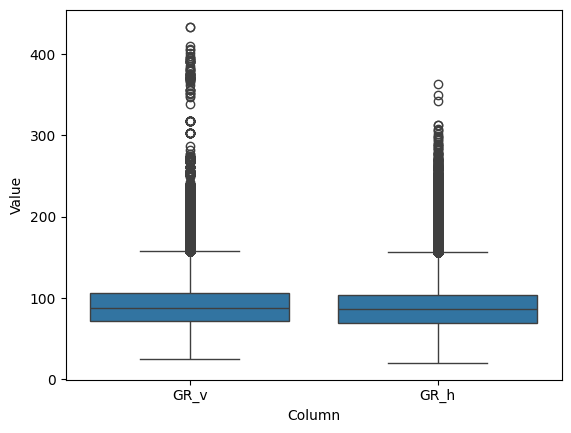

In [9]:
grs = train_df[['GR_v', 'GR_h']].melt(var_name='Column', value_name='Value')
sns.boxplot(grs, x='Column', y = 'Value')

In [10]:
train_df[['X', 'Y', 'Z']].describe()

,X,Y,Z
count,1308266.00,1308266.00,1308266.00
mean,2967537.83,1075336.05,-9283.63
std,46738.40,35326.51,654.97
min,2858892.37,1007175.50,-10841.23
25%,2921677.28,1041347.90,-9797.05
50%,2986783.91,1082701.82,-9164.50
75%,3007407.38,1104753.30,-8809.02
max,3037463.83,1138105.78,-7174.22


In [11]:
test_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v'], dtype='object')

In [12]:
train_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL',
       'BUDA', 'TVT', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v', 'Geology'],
      dtype='object')

# data processing

In [13]:
def data_processing(df): 
    df = df.sort_values(by = ['id', 'MD'])
    df = df.drop(['TVT_input', 'TVT_v'], axis = 1)
    if 'ANCC' in df.columns: 
        df = df.drop(['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL','BUDA','Geology'], axis = 1)
    # get angle of that well for different MD
    window = 5
    #df[['dMD', 'dZ']] = df.groupby('id')[['MD', 'Z']].diff(periods=window)
    #df['theta'] = (df['dZ']/df['dMD']).abs()
    #df['theta'] = df['theta'].ffill().bfill()
    #df[['dMD', 'dZ']] =  df[['dMD', 'dZ']].bfill()
    #df = df.drop(['dMD', 'GR_h', 'Y'], axis = 1)
    #df['relative_MD'] = df.groupby('id')['MD'].transform(lambda x: (x - x.min())/(x.max()-x.min()))
    #df['GR_v_rmean'] =  df.groupby('id')['GR_v'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    #df['GR_v_rstd'] =  df.groupby('id')['GR_v'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    #df['GR_h_rmean'] =  df.groupby('id')['GR_h'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    #df['GR_h_rstd'] =  df.groupby('id')['GR_h'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['GR_h'] = df['GR_h'].fillna(-999)
    #df['X_rmean'] = df.groupby('id')['X'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    #df['Y_rmean'] = df.groupby('id')['Y'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    #df[['GR_v_rmean']] =  df[['GR_v_rmean']].bfill()

    rScaler = RobustScaler()
    mScaler = MinMaxScaler(feature_range=(0, 1))
    num_cols = df.select_dtypes(include='number').columns.tolist()
    
    if 'TVT' in num_cols: num_cols.remove('TVT')
    num_cols.remove('MD')
    #num_cols.remove('relative_MD')
    df[num_cols] = rScaler.fit_transform(df[num_cols])
    df[num_cols] = mScaler.fit_transform(df[num_cols])

    ids =df['id'].unique()
    id_dict = dict(zip(ids, range(len(ids))))
    df['id'] = df['id'].map(id_dict)
    return df

In [14]:
train_df_p = data_processing(train_df.copy())
test_df_p = data_processing(test_df.copy())

In [15]:
train_df_p.isnull().sum()

id      0
MD      0
X       0
Y       0
Z       0
TVT     0
GR_h    0
GR_v    0
dtype: int64

<Axes: >

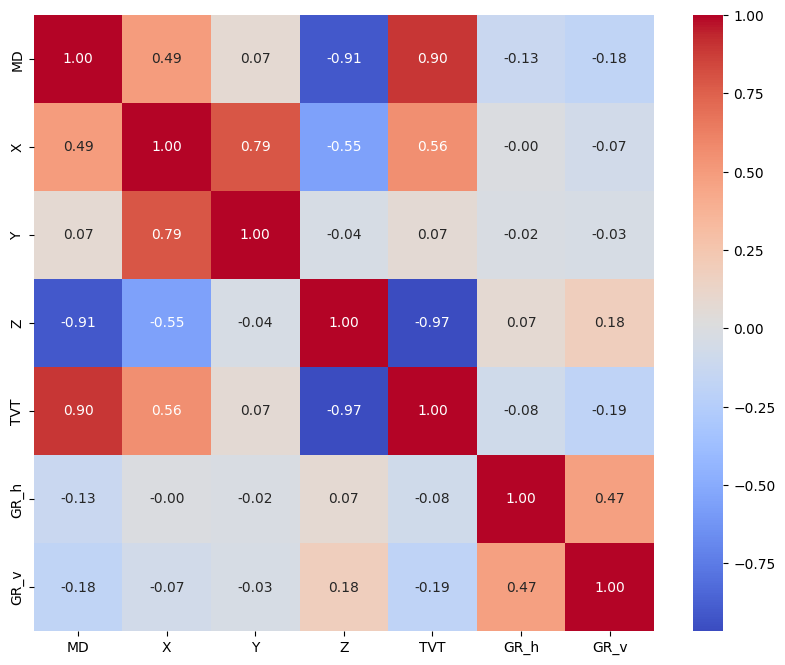

In [16]:
corr_mat = train_df_p.drop('id', axis = 1).corr(method = 'spearman')
plt.figure(figsize = (10,8))
sns.heatmap(corr_mat, cmap = 'coolwarm', annot=True, fmt = '.2f')

# Baseline 
## XGBoost
(note: this task is sequential, so xgboost isn't a good fit, but im just testing the most astray model)

In [17]:
xgb = XGBRegressor()
y = train_df_p.pop('TVT')

groups = train_df_p['id']
cv = GroupKFold()
scores = cross_val_score(xgb, train_df_p.drop('MD', axis=1), y, cv = cv, groups = groups,  scoring = 'neg_root_mean_squared_error')
scores = -scores
print(scores)
print(sum(scores)/len(scores))

[134.44195875  97.65636514 105.13125845 117.89542913 100.81166703]
111.18733570080292


## One Layer GRU

In [18]:
q75_mu = train_df_p['id'].quantile(0.75)

In [19]:
id_test = 1
obj_mask = train_df_p['id']==id_test
obj_features = train_df_p.loc[obj_mask].drop(columns=['id', 'MD'])

In [20]:
def create_manual_windows(df, y_series, timesteps):
    #df = df.reset_index(drop=True)
    #y_series = y_series.reset_index(drop=True)
    
    seq_len = timesteps
    n_features = (df.shape[1] - 2) * 2
    
    for obj_id in df['id'].unique():
        obj_mask = df['id'] == obj_id
        obj_features = df.loc[obj_mask].drop(columns=['id', 'MD'])
        obj_targets = y_series[obj_mask].values
        
        if obj_features.shape[0] < 2:
            continue
        
        for i in range(0, obj_features.shape[0] - timesteps + 1, timesteps):
            X_dwt= obj_features.iloc[i:i+timesteps].values
            if(X_dwt.shape[0]==0): 
                print(i)
                print(obj_id)
            y_dwt = obj_targets[i:i+timesteps]
            
            #cA_X_list, cD_X_list = [], []
            #for col_idx in range(X_window.shape[1]):
            #    cA, cD = pywt.dwt(X_window[:, col_idx], 'haar')
            #    cA_X_list.append(cA)
            #    cD_X_list.append(cD)
            
            #X_CA = np.column_stack(cA_X_list).astype(np.float32)
            #X_CD = np.column_stack(cD_X_list).astype(np.float32)
            #y_CA, y_CD = pywt.dwt(y_window, 'haar')
            
            #X_dwt = np.concatenate([X_CA, X_CD], axis=1)
            #y_dwt = np.column_stack([y_CA, y_CD]).astype(np.float32)
            
            # Verify shape
            if X_dwt.shape[0] != seq_len:
                print(f"Warning: Full window produced {X_dwt.shape[0]} instead of {seq_len}")
            
            yield X_dwt, y_dwt
        
        # ⭐ HANDLE PARTIAL WINDOW WITH PROPER PADDING ⭐
        # Get the remaining data after the last full window
        total_samples = obj_features.shape[0]
        last_full_end = (total_samples // timesteps) * timesteps
        remaining_samples = total_samples - last_full_end
        
        if remaining_samples >= 2:
            # Take the partial window from the end
            X_window = obj_features.iloc[last_full_end:].values
            y_window = obj_targets[last_full_end:]
            
            # Apply DWT
            #cA_X_list, cD_X_list = [], []
            #for col_idx in range(X_window.shape[1]):
            #    cA, cD = pywt.dwt(X_window[:, col_idx], 'haar')
            #    cA_X_list.append(cA)
            #    cD_X_list.append(cD)
            
            #X_CA = np.column_stack(cA_X_list).astype(np.float32)
            #X_CD = np.column_stack(cD_X_list).astype(np.float32)
            #y_CA, y_CD = pywt.dwt(y_window, 'haar')
            
            #X_dwt = np.concatenate([X_CA, X_CD], axis=1)
            #y_dwt = np.column_stack([y_CA, y_CD]).astype(np.float32)
            
            # ⭐ FORCE PAD TO seq_len ⭐
            #current_len = X_dwt.shape[0]
            #if current_len < seq_len:
            #    pad_len = seq_len - current_len
            #    X_dwt = np.pad(X_dwt, ((0, pad_len), (0, 0)), mode='constant', constant_values=0)
            #    #y_dwt = np.pad(y_dwt, ((0, pad_len), (0, 0)), mode='constant', constant_values=0)
            #elif current_len > seq_len:
                # Truncate if somehow longer (shouldn't happen)
            #    X_dwt = X_dwt[:seq_len]
                #y_dwt = y_dwt[:seq_len]
            
            # Verify shape
            if X_dwt.shape[0] != seq_len:
                print(f"Warning: Partial window produced {X_dwt.shape[0]} instead of {seq_len}")
                print(f"  Original X_window shape: {X_window.shape}")
                print(f"  DWT length: {current_len}")
                print(f"  Pad length: {pad_len if current_len < seq_len else 0}")
            
            yield X_dwt, y_dwt

In [21]:
tmp = create_manual_windows(train_df_p, y, 50)

In [22]:
for X_tmp, y_tmp in tmp:
    if X_tmp.shape[0]!=50: 
        print(X_tmp.shape[0])

In [23]:
tmp = create_manual_windows(train_df_p, y, 50)
X0, y0 = next(tmp)
print(X0.shape)
print(y0.shape)

(50, 5)
(50,)


In [24]:
train_tmp = train_df_p.loc[train_df_p.id==groups[0]].drop(['id', 'MD'], axis=1)
cA_all, cD_all = {}, {}
for c in train_tmp.columns:
    cA, cD = pywt.dwt(train_tmp[c], 'haar')
    cA_all[c] = cA
    cD_all[c] = cD
cA_all = pd.DataFrame(cA_all)
cD_all = pd.DataFrame(cD_all)

In [25]:
y_tmp = y.loc[train_df_p.id==groups[0]]
cA_y, cD_y = pywt.dwt(y_tmp, 'haar')
print(cA_y.max(), cA_y.min())
print(cD_y.max(), cD_y.min())

17062.875538761047 15649.178164338216
0.035355339059606194 -1.3717871555036254


Text(0.5, 1.0, 'Detailed')

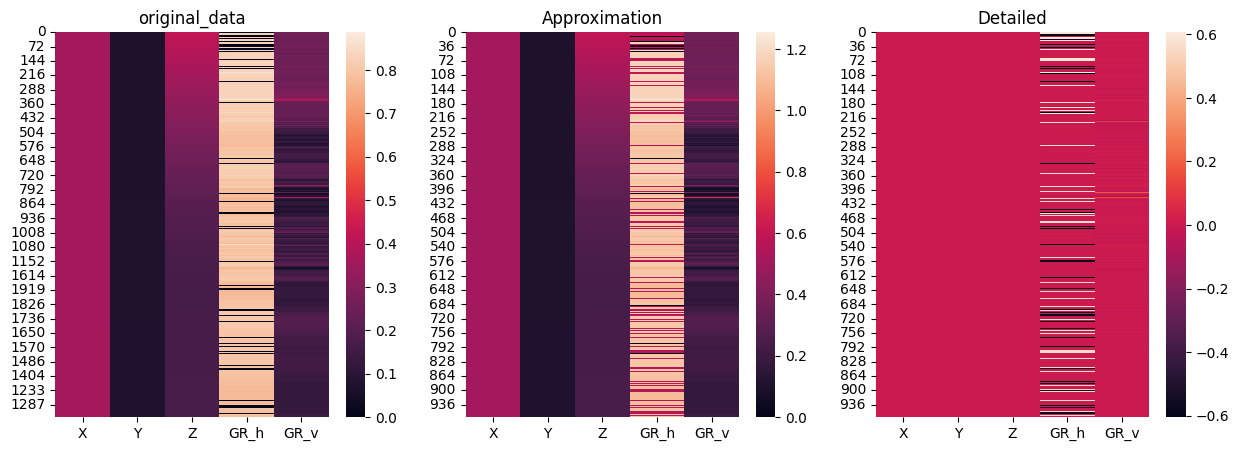

In [26]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5))
sns.heatmap(train_tmp, ax = ax[0])
sns.heatmap(cA_all, ax = ax[1])
sns.heatmap(cD_all, ax = ax[2])
#sns.heatmap(cV, ax = ax[3])
#sns.heatmap(cD, ax = ax[4])
ax[0].set_title('original_data')
ax[1].set_title('Approximation')
ax[2].set_title('Detailed')
#ax[3].set_title('Vertical Detail')
#ax[4].set_title('Diagonal Detail')

In [27]:
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices being used for parallel processing: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices being used for parallel processing: 2


I0000 00:00:1785562671.647339      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785562671.653438      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [28]:
np.random.seed(42)
id_train = np.random.choice(train_df_p['id'].unique(), 300)

In [29]:
gkf = GroupKFold(n_splits=3, shuffle=True, random_state=42)
fold_counter = 0

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df_p, y, groups=groups)):
    print(f'\n{"="*50}')
    print(f'Fold: {fold}')
    print(f'{"="*50}')
    
    X_train = train_df_p.iloc[train_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    X_val = train_df_p.iloc[val_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)
    
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"y_val shape: {y_val.shape}")
    
    # Check windows
    tmp = list(create_manual_windows(X_train, y_train, 50))  # Convert to list to count
    print(f"\nTotal windows created: {len(tmp)}")
    
    if len(tmp) == 0:
        print("⚠️ WARNING: No windows created!")
        continue
    
    # Check all windows for errors
    errors_found = 0
    for idx, (X_tmp, y_tmp) in enumerate(tmp):
        has_error = False
        
        if X_tmp.shape[0] != 50:
            print(f"  ❌ Window {idx}: X_tmp.shape[0] = {X_tmp.shape[0]} (expected 50)")
            has_error = True
            
        if X_tmp.shape[1] != X_train.shape[1]-2:
            print(f"  ❌ Window {idx}: X_tmp.shape[1] = {X_tmp.shape[1]} (expected 5)")
            has_error = True
            
        if y_tmp.shape[0] != 50:
            print(f"  ❌ Window {idx}: y_tmp.shape[0] = {y_tmp.shape[0]} (expected 50)")
            has_error = True
            
        try: 
            print(y_tmp.shape[1])
        except IndexError: 
            pass
        
        if has_error:
            errors_found += 1
            # Print first 3 errors only to avoid spam
            if errors_found <= 3:
                print(f"    X_tmp.shape: {X_tmp.shape}, y_tmp.shape: {y_tmp.shape}")
    
    if errors_found == 0:
        print("✅ All windows have correct shapes!")
    else:
        print(f"⚠️ Found {errors_found} windows with shape errors")
    
    # Also check first and last window as samples
    if len(tmp) > 0:
        print(f"\nSample window 0: X={tmp[0][0].shape}, y={tmp[0][1].shape}")
        if len(tmp) > 1:
            print(f"Sample window {len(tmp)-1}: X={tmp[-1][0].shape}, y={tmp[-1][1].shape}")
    
    fold_counter += 1


Fold: 0
X_train shape: (870389, 7)
y_train shape: (870389,)
X_val shape: (437877, 7)
y_val shape: (437877,)

Total windows created: 17626
✅ All windows have correct shapes!

Sample window 0: X=(50, 5), y=(50,)
Sample window 17625: X=(50, 5), y=(50,)

Fold: 1
X_train shape: (870383, 7)
y_train shape: (870383,)
X_val shape: (437883, 7)
y_val shape: (437883,)

Total windows created: 17629
✅ All windows have correct shapes!

Sample window 0: X=(50, 5), y=(50,)
Sample window 17628: X=(50, 5), y=(50,)

Fold: 2
X_train shape: (875760, 7)
y_train shape: (875760,)
X_val shape: (432506, 7)
y_val shape: (432506,)

Total windows created: 17735
✅ All windows have correct shapes!

Sample window 0: X=(50, 5), y=(50,)
Sample window 17734: X=(50, 5), y=(50,)


In [30]:
def create_all_windows(df, y_series, timestep):
    X_windows, y_windows = [], []
    for x_win, y_win in create_manual_windows(df, y_series, timestep):
        X_windows.append(x_win)
        y_windows.append(y_win)
    
    if len(X_windows) == 0:
        return np.array([]), np.array([])
    
    return np.array(X_windows, dtype=np.float32), np.array(y_windows, dtype=np.float32)

In [31]:
inputs = Input(shape=(50, 5))
x = Conv1D(512, 
           kernel_size=3, 
           padding='same', 
           name='cnn256', 
           kernel_initializer='he_uniform',
           kernel_regularizer=regularizers.l1_l2(l1=5e-4, l2=5e-4))(inputs)
x = BatchNormalization(name='bn_cnn256')(x)
x = Activation('relu', name='relu_cnn256')(x)
x = Conv1D(256, 
           kernel_size=3, 
           padding='same', 
           name='cnn128', 
           kernel_initializer='he_uniform',
           kernel_regularizer=regularizers.l1_l2(l1=5e-4, l2=5e-4))(x)
x = BatchNormalization(name='bn_cnn128')(x)
x = Activation('relu', name='relu_cnn128')(x)
x = Conv1D(128, 
           kernel_size=3, 
           padding='same', 
           name='cnn64', 
           kernel_initializer='he_uniform',
           kernel_regularizer=regularizers.l1_l2(l1=5e-4, l2=5e-4))(x)
x = Dropout(0.1, seed=42)(x)
x = BatchNormalization(name='bn_cnn64')(x)
x = Activation('relu', name='relu_cnn64')(x)

x = TransformerEncoder(intermediate_dim=256, num_heads=4)(x)
x = Bidirectional(GRU(128, 
                      return_sequences=True, 
                      kernel_regularizer=regularizers.l1_l2(l1=5e-4, l2=5e-4)))(x)
x = Dense(128, 
          activation='relu', 
          kernel_initializer='he_uniform',
          kernel_regularizer=regularizers.l1_l2(l1=1e-3, l2=1e-3))(x)
x = Dense(64, 
          activation='relu', 
          kernel_initializer='he_uniform', 
          kernel_regularizer=regularizers.l1_l2(l1=1e-3, l2=1e-3))(x)
x = Dense(32, activation='relu', kernel_initializer='he_uniform')(x)
x = BatchNormalization(momentum=0.995)(x)
x = Dropout(0.3, seed=42)(x)

outputs = Dense(1, activation='linear')(x)

model = Model(inputs=inputs, outputs=outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)

model.compile(optimizer='adam', loss='mse')
model.optimizer.learning_rate.assign(1e-4)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn256 (Conv1D)                 │ (None, 50, 512)        │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_cnn256 (BatchNormalization)  │ (None, 50, 512)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_cnn256 (Activation)        │ (None, 50, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn128 (Conv1D)                 │ (None, 50, 256)        │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_cnn128 (BatchNormalization)  │ (None, 50, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_cnn128 (Activation)        │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn64 (Conv1D)                  │ (None, 50, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_cnn64 (BatchNormalization)   │ (None, 50, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_cnn64 (Activation)         │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 50, 128)        │       132,480 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50, 1)          │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 877,697 (3.35 MB)

 Trainable params: 875,841 (3.34 MB)

 Non-trainable params: 1,856 (7.25 KB)

In [32]:
gkf = GroupKFold(n_splits=3, shuffle=True, random_state=42)
scores = []

output_dir = '/kaggle/working/model_logs'
os.makedirs(output_dir, exist_ok=True)

timestep = 100
fold_counter = 0
features = (train_df_p.shape[1] - 2)  
print(f"Number of features: {features}")

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df_p, y, groups=groups)):
    X_train = train_df_p.iloc[train_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    X_val = train_df_p.iloc[val_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)
    print(f'Index of X_train: {X_train.index}')
    print(f'Index of y_train: {y_train.index}')
    # ⭐ CREATE ALL WINDOWS AS NUMPY ARRAYS ⭐
    X_train_windows, y_train_windows = create_all_windows(X_train, y_train, timestep)
    X_val_windows, y_val_windows = create_all_windows(X_val, y_val, timestep)
    
    print(f"Train windows: {X_train_windows.shape}, {y_train_windows.shape}")
    print(f"Val windows: {X_val_windows.shape}, {y_val_windows.shape}")

    keras.utils.set_random_seed(42)
    with strategy.scope():
        inputs = Input(shape=(timestep, features))
        x = Conv1D(512, 
                   kernel_size=3, 
                   padding='same', 
                   name='cnn256', 
                   kernel_initializer='he_uniform')(inputs)
        x = BatchNormalization(name='bn_cnn256')(x)
        x = Activation('relu', name='relu_cnn256')(x)
        x = Conv1D(256, 
                   kernel_size=3, 
                   padding='same', 
                   name='cnn128', 
                   kernel_initializer='he_uniform')(x)
        x = BatchNormalization(name='bn_cnn128')(x)
        x = Activation('relu', name='relu_cnn128')(x)
        x = Conv1D(128, 
                   kernel_size=3, 
                   padding='same', 
                   name='cnn64', 
                   kernel_initializer='he_uniform')(x)
        x = BatchNormalization(name='bn_cnn64')(x)
        x = Activation('relu', name='relu_cnn64')(x)
        x = TransformerEncoder(intermediate_dim=512, num_heads=4)(x)
        x = Bidirectional(GRU(128, 
                              return_sequences=True, 
                              kernel_regularizer=regularizers.l1_l2(l1=1e-3, l2=1e-3)))(x)
        x = Dropout(0.1, seed=42)(x)
        x = Dense(128, 
                  activation='relu', 
                  kernel_initializer='he_uniform',
                  kernel_regularizer=regularizers.l1_l2(l1=1e-3, l2=1e-3))(x)
        x = Dense(64, 
                  activation='relu', 
                  kernel_initializer='he_uniform', 
                  kernel_regularizer=regularizers.l1_l2(l1=1e-3, l2=1e-3))(x)
        x = Dense(32, 
                  activation='relu', 
                  kernel_initializer='he_uniform',
                  kernel_regularizer=regularizers.l1_l2(l1=1e-3, l2=1e-3))(x)
        x = BatchNormalization(momentum=0.995)(x)
        x = Dropout(0.1, seed=42)(x)
        
        outputs = Dense(1, activation='linear')(x)
        
        model = Model(inputs=inputs, outputs=outputs)

        optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)
        

        model.compile(optimizer=optimizer, 
                      loss='mse',
                    
        )

    csv_logger = tf.keras.callbacks.CSVLogger(
        filename=os.path.join(output_dir, f'epoch_logs{fold_counter}.csv'),
        append=False,
        separator=','
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',     
        patience=15,          
        restore_best_weights=True 
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',   
        factor=0.5,           
        patience=5,           
        min_lr=1e-7,          
        verbose=1             
    )
    
    history = model.fit(
        X_train_windows, y_train_windows,
        validation_data=(X_val_windows, y_val_windows),
        epochs=500, 
        verbose=1,  
        callbacks=[early_stopping, csv_logger, reduce_lr] 
    )
    
    loss = min(history.history['val_loss'])
    scores.append(np.sqrt(loss))
    print(f"Fold {fold}: RMSE = {np.sqrt(loss):.4f}")
    fold_counter += 1

print(f"\nAverage Cross-Validation RMSE across all groups: {np.mean(scores):.4f}")

Number of features: 5
Index of X_train: RangeIndex(start=0, stop=870389, step=1)
Index of y_train: RangeIndex(start=0, stop=870389, step=1)
Train windows: (8967, 100, 5), (8967, 100)
Val windows: (4518, 100, 5), (4518, 100)
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 1/500
INFO:tensorflow:Collective all_reduce tensors: 44 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


I0000 00:00:1785562687.874244      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1785562689.000162      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 129560464.0000INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - loss: 129560248.0000 - val_loss: 131291384.0000 - l